In [2]:
import pandas as pd 

In [3]:
df=pd.read_csv(r"C:\Users\gdcgd\Downloads\Titanic-Dataset.csv.xls")

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.shape

(891, 12)

In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [10]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Data Cleaing

## Remove null values

In [11]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [12]:
df['Age'].skew()

np.float64(0.38910778230082704)

In [13]:
df['Age']=df['Age'].fillna(df['Age'].mean())

In [14]:
df=df.drop('Cabin',axis=1)

In [15]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       2
dtype: int64

In [16]:
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])

# check Duplicates values

In [17]:
print(df.duplicated().sum())

0


## check outliers

In [18]:
import numpy as np 
a=df.select_dtypes(include=np.number)

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings(action='ignore')

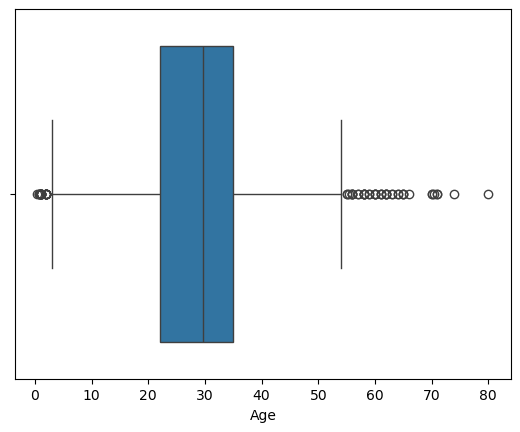

In [20]:
sns.boxplot(data=df,x='Age')
plt.show()

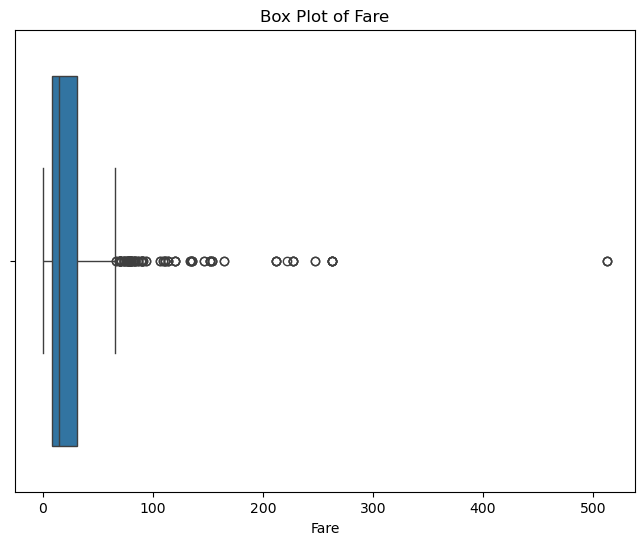

In [21]:
plt.figure(figsize=(8,6))
sns.boxplot(x=df['Fare'])
plt.title("Box Plot of Fare")
plt.show()

<Axes: >

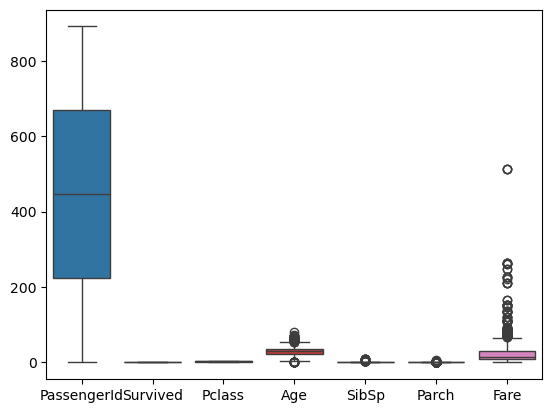

In [22]:
sns.boxplot(df)

In [30]:
for i in a:
    q1=a[i].quantile(0.25)
    q2=a[i].quantile(0.50)
    q3=a[i].quantile(0.75)
    IQR=q3-q1
    Uw=q3+1.5*IQR 
    Lw=q1-1.5*IQR
    outlier=(a[i]>Uw)|(a[i]<Lw)
    print(outlier.sum())
    a.

0
0
0
66
46
213
116


In [31]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')

In [46]:
df['PassengerId'].value_counts()

PassengerId
1      1
2      1
3      1
4      1
5      1
      ..
887    1
888    1
889    1
890    1
891    1
Name: count, Length: 891, dtype: int64

In [59]:
a=df['Survived'].value_counts()

In [63]:
b=df.groupby('Sex')['Survived'].mean()*100

### most of female survived in titanic 

## BINING

In [53]:
bins=[0,18,40,70]
labels=['child','adult','old']
df['Agegroup']=pd.cut(df['Age'],bins=bins,labels=labels)

In [76]:
c=df.groupby('Agegroup')['Survived'].mean()*100

## child survived more in incident

In [84]:
df.sort_values(by='Fare',ascending=False)

### the people who are spending more survived more 

In [86]:
d=df.groupby('Pclass')['Survived'].mean()*100

## passengers from class_1 are surviving more

# DATA VISUALISATION

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns 

<BarContainer object of 2 artists>

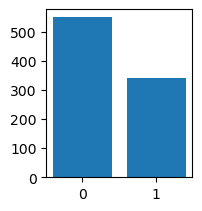

In [60]:
plt.subplot(2,3,1)
plt.bar(a.index,a.values)

In [ ]:
line chart for showing trends (one cat and num)

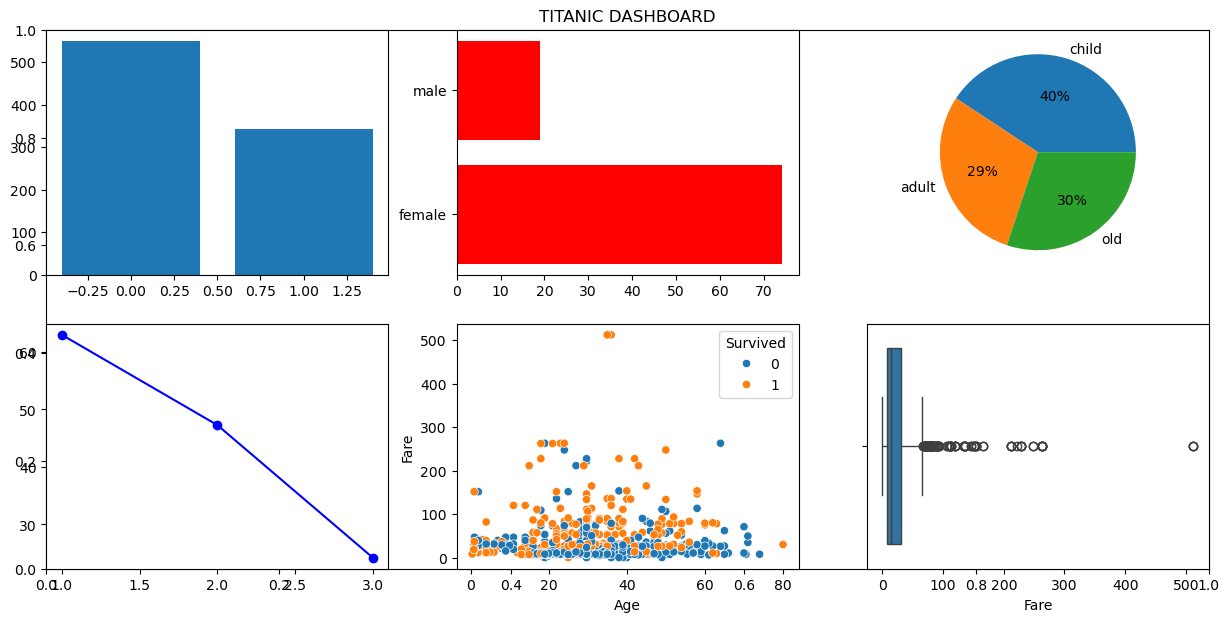

In [94]:
plt.figure(figsize=(15,7))
plt.title('TITANIC DASHBOARD')
plt.subplot(2,3,1)
plt.bar(a.index,a.values)
plt.subplot(2,3,2)
plt.barh(b.index,b.values,color='red')
plt.subplot(2,3,3)
plt.pie(c.values,labels=c.index,autopct='%1d%%')
plt.subplot(2,3,4)
plt.plot(d.index,d.values,marker="o",color="blue")
plt.subplot(2,3,5)
sns.scatterplot(x='Age',y='Fare',hue="Survived",data=df)
plt.subplot(2,3,6)
sns.boxplot(x="Fare",data=df)
plt.show()

